# 01 - Exploratory Data Analysis
**Airline Customer Satisfaction & Loyalty Analytics**

Explores the cleaned Kaggle *Airline Passenger Satisfaction* data (129,880 passengers) before modelling it in Power BI.

Prerequisite: `python scripts/download_data.py && python scripts/clean.py`

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
from clean import SERVICE_COLUMNS, SERVICE_LABELS, AGE_BANDS, DELAY_BUCKETS, DISTANCE_BANDS

SAT, DIS = '#2a78d6', '#eb6834'   # satisfied / dissatisfied
INK, MUTED, GRID = '#0b0b0b', '#52514e', '#e8e7e2'
plt.rcParams.update({
    'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#d0cfca', 'axes.labelcolor': MUTED, 'xtick.color': MUTED,
    'ytick.color': MUTED, 'axes.titlecolor': INK, 'axes.titleweight': 'bold',
    'axes.titlelocation': 'left', 'axes.grid': True, 'grid.color': GRID, 'axes.axisbelow': True,
})
SHOTS = ROOT / 'screenshots'

df = pd.read_csv(ROOT / 'data' / 'processed' / 'flights_clean.csv')
print(df.shape)
df.head()

(129880, 32)


,passenger_id,gender,customer_type,age,travel_type,class,flight_distance,inflight_wifi_service,departure_arrival_time_convenient,ease_of_online_booking,...,arr_delay,satisfaction,source_split,age_band,delay_bucket,distance_band,is_satisfied,is_delayed_15,services_not_applicable,avg_service_rating
0,1,Male,Disloyal Customer,48,Business Travel,Business,821,3,3,3,...,5,neutral or dissatisfied,train,46-60,1-15 min,Short (<1000),0,0,0,3.857
1,2,Female,Loyal Customer,35,Business Travel,Business,821,2,2,2,...,39,satisfied,train,31-45,16-60 min,Short (<1000),1,1,0,3.786
2,3,Male,Loyal Customer,41,Business Travel,Business,853,4,4,4,...,0,satisfied,train,31-45,On time,Short (<1000),1,0,0,3.929
3,4,Male,Loyal Customer,50,Business Travel,Business,1905,2,2,2,...,0,satisfied,train,46-60,On time,Medium (1000-3000),1,0,0,3.786
4,5,Female,Loyal Customer,49,Business Travel,Business,3470,3,3,3,...,1,satisfied,train,46-60,On time,Long (3000+),1,0,0,3.500


## 1. Data quality

In [2]:
raw = pd.concat([pd.read_csv(ROOT / 'data' / 'raw' / f) for f in ('train.csv', 'test.csv')])
print('Raw rows:', len(raw))
print('Missing values in raw data:')
print(raw.isna().sum()[lambda s: s > 0])
print('\nDuplicate passenger ids:', raw['id'].duplicated().sum())
print('Missing after cleaning:', df.isna().sum().sum())

Raw rows: 129880
Missing values in raw data:
Arrival Delay in Minutes    393
dtype: int64

Duplicate passenger ids: 0
Missing after cleaning: 0


In [3]:
# Rating 0 = 'not applicable' (e.g. no Wi-Fi on board) - share per service
na_share = (df[SERVICE_COLUMNS] == 0).mean().rename(lambda c: SERVICE_LABELS[c][0])
na_share.sort_values(ascending=False).map('{:.1%}'.format).to_frame('rated 0 (N/A)')

,rated 0 (N/A)
Departure/Arrival Time,5.1%
Online Booking,4.4%
Inflight Wi-Fi,3.0%
Online Boarding,2.4%
Leg Room,0.5%
Food & Drink,0.1%
Inflight Entertainment,0.0%
Cleanliness,0.0%
Inflight Service,0.0%
On-board Service,0.0%


## 2. Target: how many passengers are satisfied?

In [4]:
rate = df['is_satisfied'].mean()
print(f'Satisfied: {rate:.1%}  |  Neutral or dissatisfied: {1 - rate:.1%}')
df['satisfaction'].value_counts()

Satisfied: 43.4%  |  Neutral or dissatisfied: 56.6%


satisfaction
neutral or dissatisfied    73452
satisfied                  56428
Name: count, dtype: int64

## 3. Satisfaction by segment

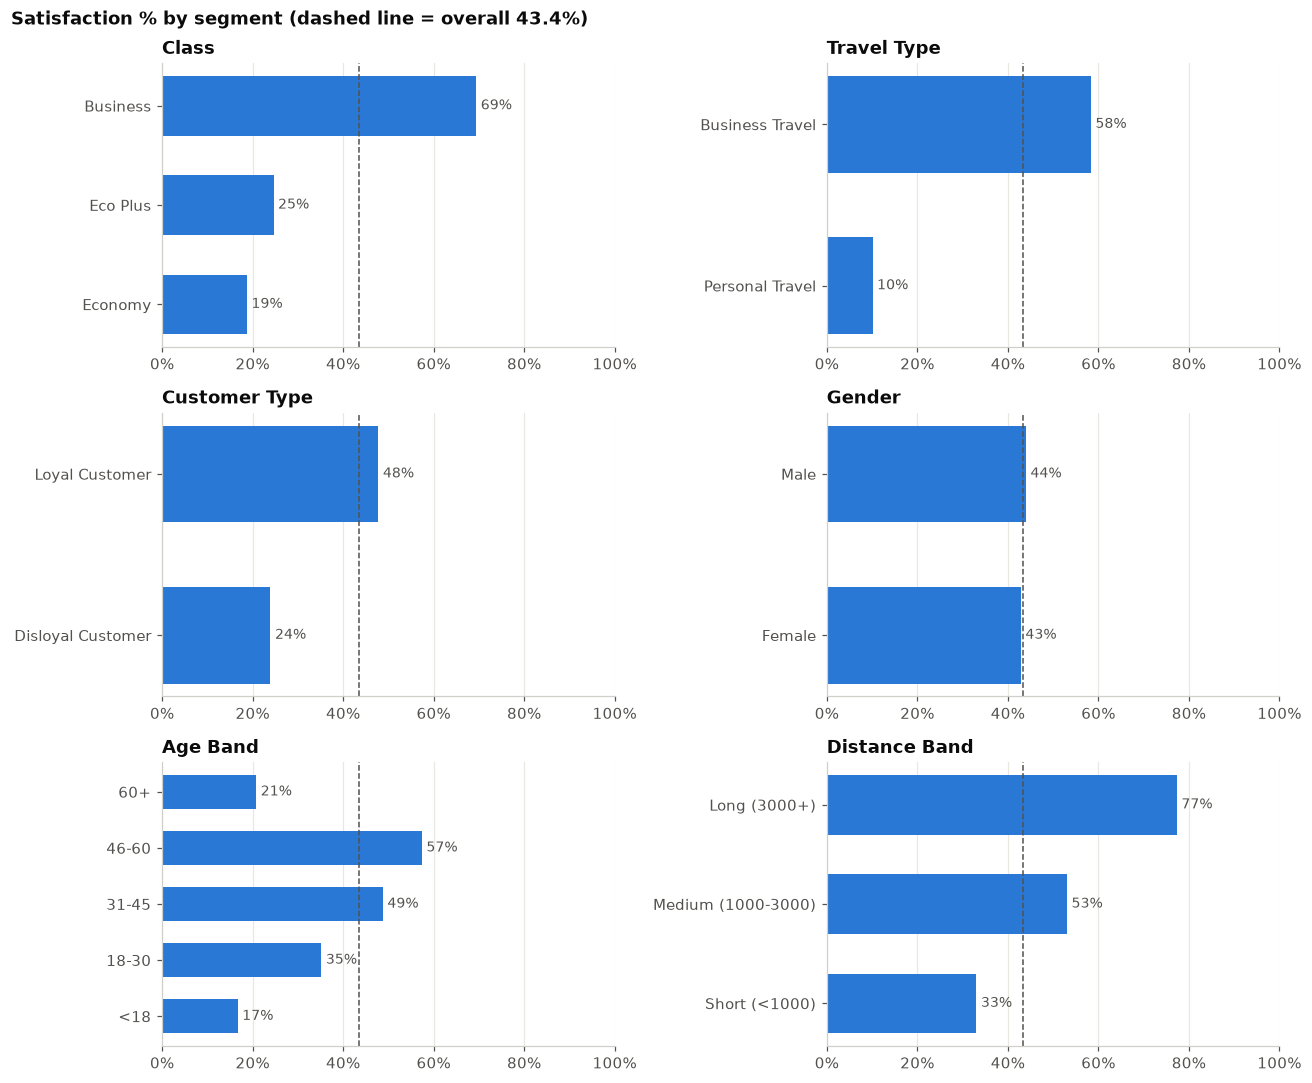

In [5]:
def sat_by(col, order=None, ax=None):
    s = df.groupby(col)['is_satisfied'].mean()
    s = s.reindex(order) if order else s.sort_values()
    ax.barh(s.index.astype(str), s.values, color=SAT, height=0.6)
    ax.axvline(rate, color=MUTED, lw=1, ls='--')
    for y, v in enumerate(s.values):
        ax.text(v + 0.01, y, f'{v:.0%}', va='center', fontsize=9, color=MUTED)
    ax.set_xlim(0, 1); ax.xaxis.set_major_formatter('{x:.0%}'); ax.grid(axis='y', visible=False)
    ax.set_title(col.replace('_', ' ').title())

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
sat_by('class', ['Economy', 'Eco Plus', 'Business'], axes[0, 0])
sat_by('travel_type', ax=axes[0, 1])
sat_by('customer_type', ax=axes[1, 0])
sat_by('gender', ax=axes[1, 1])
sat_by('age_band', AGE_BANDS, axes[2, 0])
sat_by('distance_band', DISTANCE_BANDS, axes[2, 1])
fig.suptitle(f'Satisfaction % by segment (dashed line = overall {rate:.1%})', x=0.01, ha='left',
             fontweight='bold', color=INK)
fig.tight_layout()
fig.savefig(SHOTS / 'eda_segments.png', facecolor='white')
plt.show()

In [6]:
# Where are the at-risk passengers? Satisfaction % by customer type x travel type x class
seg = (df.groupby(['customer_type', 'travel_type', 'class'])['is_satisfied']
         .agg(passengers='size', satisfaction='mean').reset_index())
seg['dissatisfied_passengers'] = (seg['passengers'] * (1 - seg['satisfaction'])).round().astype(int)
seg.sort_values('dissatisfied_passengers', ascending=False).style.format(
    {'satisfaction': '{:.1%}', 'passengers': '{:,}', 'dissatisfied_passengers': '{:,}'})

,customer_type,travel_type,class,passengers,satisfaction,dissatisfied_passengers
11,Loyal Customer,Personal Travel,Economy,"32,821",10.2%,"29,488"
2,Disloyal Customer,Business Travel,Economy,"13,450",14.4%,"11,517"
6,Loyal Customer,Business Travel,Business,"50,269",78.0%,"11,078"
8,Loyal Customer,Business Travel,Economy,"11,854",47.6%,"6,209"
0,Disloyal Customer,Business Travel,Business,"9,218",39.7%,"5,556"
10,Loyal Customer,Personal Travel,Eco Plus,"4,505",8.7%,"4,111"
9,Loyal Customer,Personal Travel,Business,"2,660",11.8%,"2,347"
7,Loyal Customer,Business Travel,Eco Plus,"3,991",46.4%,"2,139"
1,Disloyal Customer,Business Travel,Eco Plus,911,8.0%,838
5,Disloyal Customer,Personal Travel,Economy,184,17.4%,152


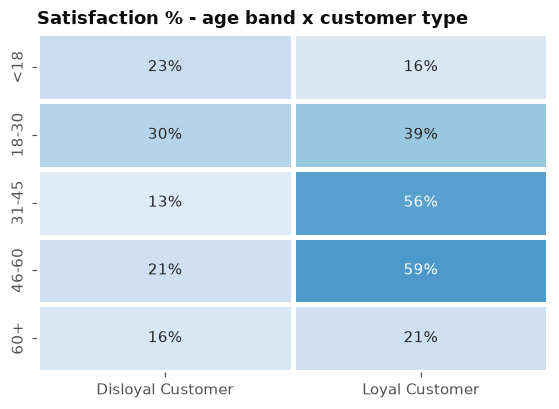

In [7]:
pivot = df.pivot_table(index='age_band', columns='customer_type', values='is_satisfied').reindex(AGE_BANDS)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(pivot, annot=True, fmt='.0%', cmap='Blues', vmin=0, vmax=1, cbar=False, ax=ax,
            linewidths=2, linecolor='white')
ax.set_title('Satisfaction % - age band x customer type'); ax.set_xlabel(''); ax.set_ylabel('')
plt.show()

## 4. Distributions

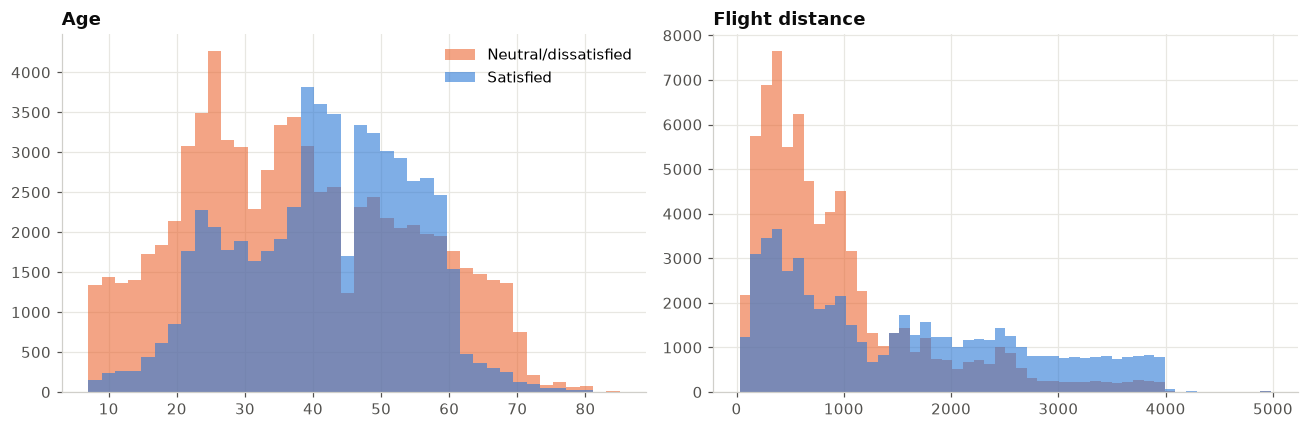

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, color, flag in (('Neutral/dissatisfied', DIS, 0), ('Satisfied', SAT, 1)):
    sub = df[df['is_satisfied'] == flag]
    axes[0].hist(sub['age'], bins=40, alpha=0.6, color=color, label=label)
    axes[1].hist(sub['flight_distance'], bins=50, alpha=0.6, color=color, label=label)
axes[0].set_title('Age'); axes[1].set_title('Flight distance')
axes[0].legend(frameon=False)
fig.tight_layout(); plt.show()

## 5. Delays

Delayed > 15 min: 22.1%
Delayed > 60 min: 6.9%
Mean departure delay: 14.7 min (median 0)
Correlation departure vs arrival delay: 0.966


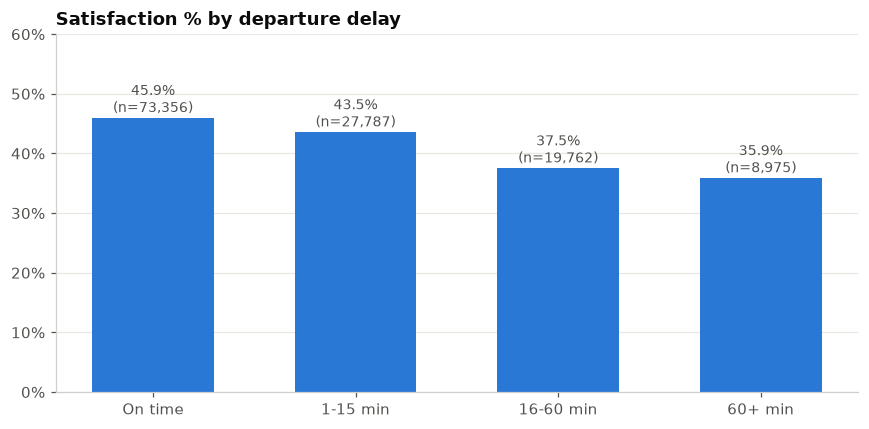

In [9]:
print(f"Delayed > 15 min: {(df['dep_delay'] > 15).mean():.1%}")
print(f"Delayed > 60 min: {(df['dep_delay'] > 60).mean():.1%}")
print(f"Mean departure delay: {df['dep_delay'].mean():.1f} min (median {df['dep_delay'].median():.0f})")
print('Correlation departure vs arrival delay:', round(df['dep_delay'].corr(df['arr_delay']), 3))

by_bucket = df.groupby('delay_bucket')['is_satisfied'].agg(['mean', 'size']).reindex(DELAY_BUCKETS)
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_bucket.index, by_bucket['mean'], color=SAT, width=0.6)
for x, (v, n) in enumerate(zip(by_bucket['mean'], by_bucket['size'])):
    ax.text(x, v + 0.01, f'{v:.1%}\n(n={n:,})', ha='center', fontsize=9, color=MUTED)
ax.set_ylim(0, 0.6); ax.yaxis.set_major_formatter('{x:.0%}'); ax.grid(axis='x', visible=False)
ax.set_title('Satisfaction % by departure delay')
fig.tight_layout(); fig.savefig(SHOTS / 'eda_delay_impact.png', facecolor='white'); plt.show()

## 6. Service ratings

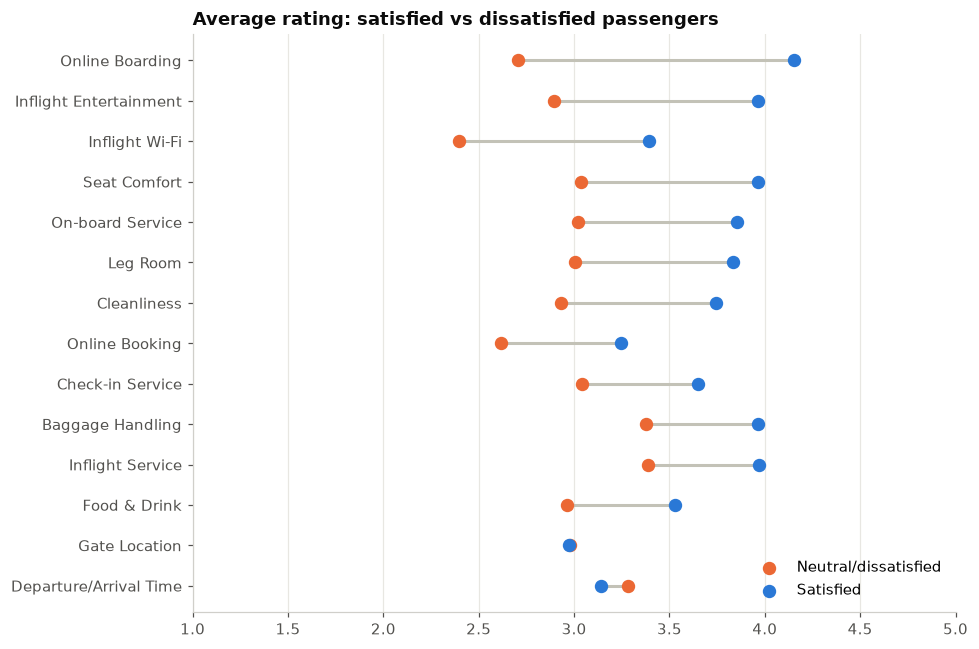

,avg_rating,satisfied,dissatisfied,gap,service_gap_vs_5
Online Boarding,3.33,4.15,2.71,1.45,1.67
Inflight Entertainment,3.36,3.96,2.89,1.07,1.64
Inflight Wi-Fi,2.81,3.39,2.40,0.99,2.19
Seat Comfort,3.44,3.97,3.04,0.93,1.56
On-board Service,3.38,3.86,3.02,0.84,1.62
Leg Room,3.37,3.83,3.01,0.83,1.63
Cleanliness,3.29,3.75,2.93,0.81,1.71
Online Booking,2.88,3.24,2.62,0.63,2.12
Check-in Service,3.31,3.65,3.04,0.61,1.69
Baggage Handling,3.63,3.97,3.37,0.59,1.37


In [10]:
ratings = df[SERVICE_COLUMNS].replace(0, np.nan)  # 0 = N/A, not a score
svc = pd.DataFrame({
    'avg_rating': ratings.mean(),
    'satisfied': ratings[df['is_satisfied'] == 1].mean(),
    'dissatisfied': ratings[df['is_satisfied'] == 0].mean(),
}).rename(index=lambda c: SERVICE_LABELS[c][0])
svc['gap'] = svc['satisfied'] - svc['dissatisfied']
svc['service_gap_vs_5'] = 5 - svc['avg_rating']
svc = svc.sort_values('gap')

fig, ax = plt.subplots(figsize=(9, 6))
y = np.arange(len(svc))
ax.hlines(y, svc['dissatisfied'], svc['satisfied'], color='#c3c2b7', lw=2)
ax.scatter(svc['dissatisfied'], y, color=DIS, s=60, label='Neutral/dissatisfied', zorder=3)
ax.scatter(svc['satisfied'], y, color=SAT, s=60, label='Satisfied', zorder=3)
ax.set_yticks(y, svc.index); ax.set_xlim(1, 5); ax.grid(axis='y', visible=False)
ax.set_title('Average rating: satisfied vs dissatisfied passengers')
ax.legend(frameon=False, loc='lower right')
fig.tight_layout(); fig.savefig(SHOTS / 'eda_service_gap.png', facecolor='white'); plt.show()
svc.sort_values('gap', ascending=False).round(2)

In [11]:
# Satisfaction jumps sharply once Wi-Fi / online boarding are rated 4+
pd.DataFrame({
    'Inflight Wi-Fi': df.groupby('inflight_wifi_service')['is_satisfied'].mean(),
    'Online Boarding': df.groupby('online_boarding')['is_satisfied'].mean(),
}).rename_axis('rating (0 = N/A)').style.format('{:.1%}')

,Inflight Wi-Fi,Online Boarding
rating (0 = N/A),,
0,99.7%,56.5%
1,32.8%,13.8%
2,24.7%,11.5%
3,25.2%,13.8%
4,60.1%,62.3%
5,99.0%,87.1%


## 7. Correlations

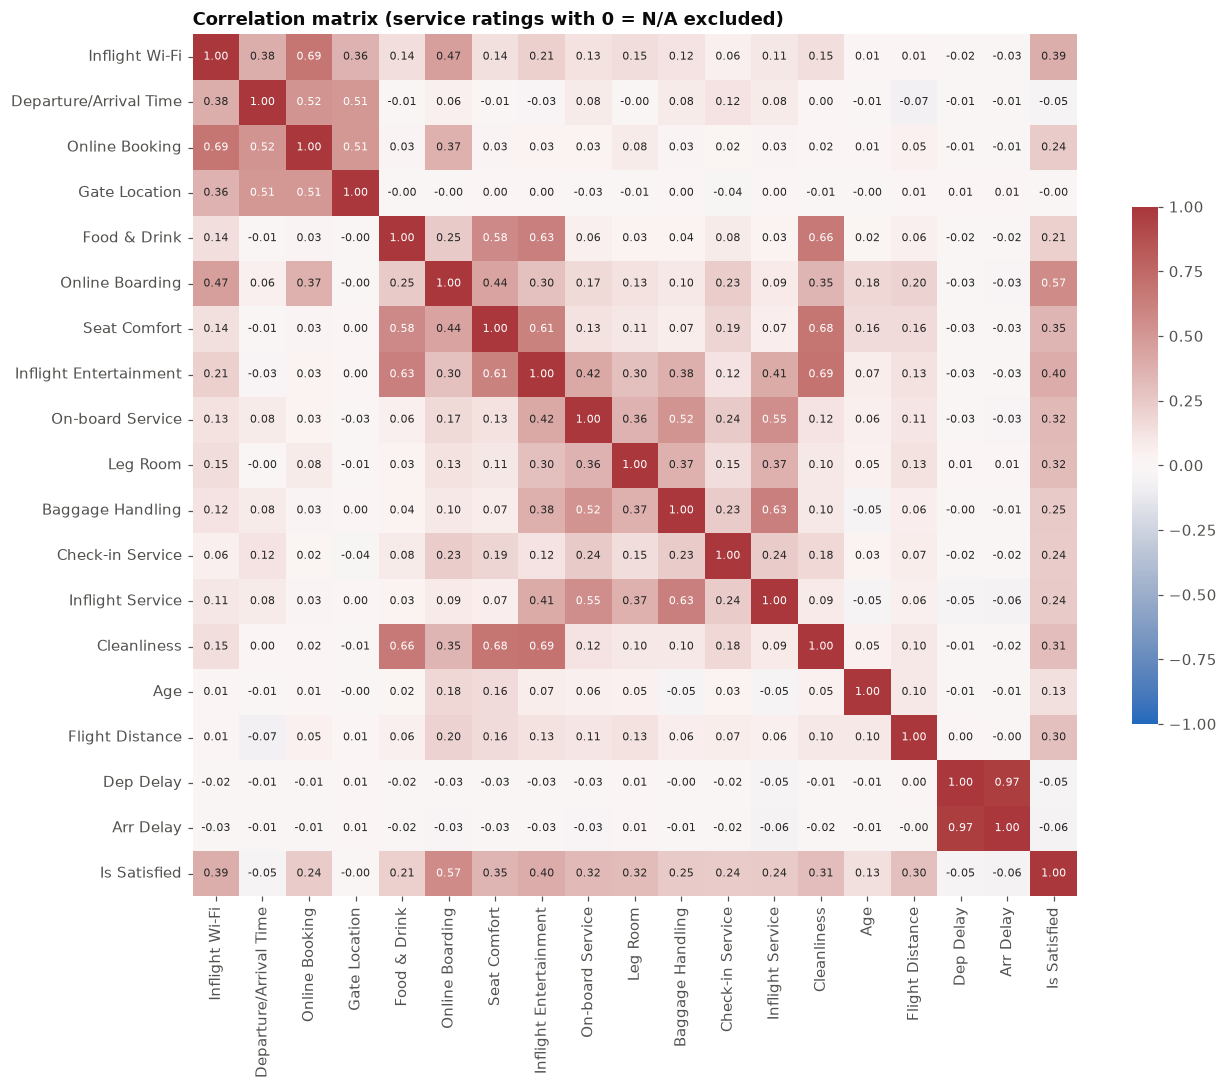

In [12]:
cols = SERVICE_COLUMNS + ['age', 'flight_distance', 'dep_delay', 'arr_delay', 'is_satisfied']
corr = df[cols].replace({c: {0: np.nan} for c in SERVICE_COLUMNS}).corr()
labels = [SERVICE_LABELS.get(c, (c.replace('_', ' ').title(),))[0] for c in cols]
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap='vlag', center=0, vmin=-1, vmax=1, annot=True, fmt='.2f',
            annot_kws={'size': 7}, xticklabels=labels, yticklabels=labels, ax=ax,
            cbar_kws={'shrink': 0.6})
ax.set_title('Correlation matrix (service ratings with 0 = N/A excluded)')
fig.tight_layout(); fig.savefig(SHOTS / 'eda_correlation.png', facecolor='white'); plt.show()

In [13]:
corr['is_satisfied'].drop('is_satisfied').rename(lambda c: SERVICE_LABELS.get(c, (c,))[0])\
    .sort_values(ascending=False).round(3).to_frame('corr with satisfaction')

,corr with satisfaction
Online Boarding,0.565
Inflight Entertainment,0.398
Inflight Wi-Fi,0.390
Seat Comfort,0.349
On-board Service,0.322
Leg Room,0.316
Cleanliness,0.307
flight_distance,0.298
Baggage Handling,0.249
Inflight Service,0.245


## 8. Takeaways
- **Class and purpose dominate**: Business class passengers are far more satisfied than Economy, and personal-travel passengers are the least satisfied group overall.
- **Loyalty matters**: disloyal customers are roughly half as likely to be satisfied as loyal ones.
- **Digital touchpoints separate the two groups**: online boarding and inflight Wi-Fi show the largest rating gaps and satisfaction jumps once they reach 4+.
- **Delays hurt, but less than service**: satisfaction falls ~9 points for departures >15 min late; departure and arrival delay are almost perfectly correlated, so only one is needed in the model.
- Several in-flight ratings (seat comfort, entertainment, cleanliness, food) are strongly correlated with each other - the driver model has to share credit between them.

Next: `python scripts/driver_analysis.py` quantifies these drivers.